# How the online tuner learns — a tutorial

This notebook explains the learning algorithm in this repository from the
ground up: what is being learned, why the gradient exists in closed form,
how TD(λ) turns one scalar reward per tick into a policy update, where the
original design goes wrong, and what fixes it. Every claim is shown on a
toy problem you can run in a few seconds with only `numpy` and
`matplotlib`; the real experiments (acados, the dynamic car model, the
scuderia plant) live in `experiments/` and are referenced at the end.

The car and the controller are only a backdrop here. The mathematics is
about a **parametric optimisation problem whose parameters are tuned by
reinforcement learning while it runs**.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
INK, MUT, GRID = "#212529", "#868E96", "#DEE2E6"
BLUE, GREEN, ORANGE, PURPLE, CYAN = "#4C6EF5", "#0CA678", "#E8590C", "#AE3EC9", "#1098AD"


def tidy(ax, title=None, xlabel=None, ylabel=None):
    """One house style for every plot in this notebook."""
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    ax.grid(True, color=GRID, lw=0.7)
    ax.set_axisbelow(True)
    ax.tick_params(colors=MUT, labelsize=9)
    if title:
        ax.set_title(title, loc="left", fontsize=11, fontweight="bold", color=INK)
    if xlabel:
        ax.set_xlabel(xlabel, color=MUT)
    if ylabel:
        ax.set_ylabel(ylabel, color=MUT)

/home/poxx/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. What is being learned

A Model Predictive Contouring Controller (MPCC) drives the car by solving,
every 50 ms, an optimisation problem over a short horizon:

$$
J^*(x, \theta) \;=\; \min_{u_{0:N}}\; \sum_{k=0}^{N}
    \Big[\, q_c\, e_{c,k}^2 + q_l\, e_{l,k}^2 - q_v\, v_{s,k}
          + r_d\, \Delta\delta_k^2 + r_a\, a_k^2 + \dots \Big]
\quad \text{s.t. dynamics, track corridor, input limits.}
$$

The **weights** $\theta = (q_c, q_l, q_v, r_d, r_a, r_{dv}, d_{obs}, k_v)$
decide the controller's character: how tightly it follows the line
($q_c$), how much it values progress ($q_v$), how hard it may steer and
accelerate ($r_d$, $r_a$), how much berth it gives an opponent ($d_{obs}$),
how much grip it claims ($k_v$). A racing engineer tunes these by hand.

The idea in this repo is to let a small recurrent network — a **weight
policy** $\pi_\phi$ — emit $\theta$ every tick from what the car can see
(curvature ahead, its speed, the sector it is in, the gap to an opponent),
and to train that network **online** from a single scalar reward per tick:

$$
\theta_t = \pi_\phi(\text{features}_t), \qquad
u_t = \arg\min J(x_t, \theta_t), \qquad
r_t = \text{progress made} \;(\text{or } -\Delta t).
$$

So there are two nested optimisations: the MPCC's, solved to (near)
optimality every tick, and the learner's, taking one small gradient step per
tick on the network parameters $\phi$. Everything below is about how that
outer step is computed and why it is delicate.

## 2. The gradient is free: the envelope theorem

The learner needs $\partial J^*/\partial\theta$ — how the controller's
optimal cost changes when a weight changes. Differentiating through an
optimiser sounds expensive, but for a parametric optimisation the
**envelope theorem** says: at the optimum, the total derivative with respect
to the parameters equals the *partial* derivative of the Lagrangian, holding
the optimal decision fixed.

$$
\frac{d J^*}{d\theta} \;=\; \frac{\partial \mathcal{L}}{\partial \theta}\Big|_{u^*,\lambda^*}
\;=\; \frac{\partial J}{\partial \theta}\Big|_{u^*} \;+\; \lambda^{*\top}\frac{\partial g}{\partial \theta}\Big|_{u^*}.
$$

When $\theta$ appears **only in the cost**, the second term vanishes and the
gradient is simply *each cost term evaluated at the solution*: for a weight
$q$ multiplying a squared error $e^2$, $\partial J^*/\partial q = \sum_k e_k^{*2}$.
No re-solve, no finite differences.

A two-weight toy shows it. Minimise $J(u;\theta) = \theta_1 (u-1)^2 + \theta_2 u^2$
over $u$. The optimum is $u^* = \theta_1/(\theta_1+\theta_2)$ and
$J^* = \theta_1\theta_2/(\theta_1+\theta_2)$, so we can check the envelope
gradient against the exact derivative and against finite differences.

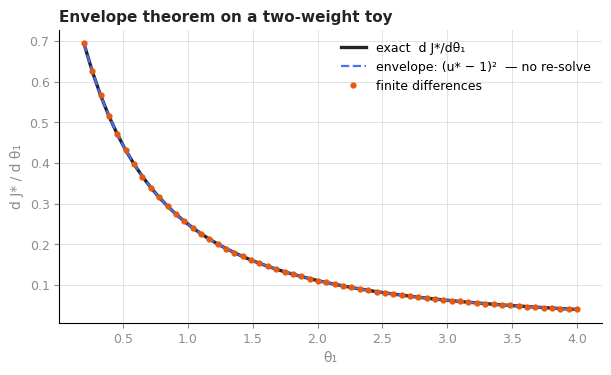

max |exact - envelope| = 1.3877787807814457e-16


In [2]:
def J_star(th1, th2):
    return th1 * th2 / (th1 + th2)


def u_star(th1, th2):
    return th1 / (th1 + th2)


def envelope_grad(th1, th2):
    """d J*/d theta_1 by the envelope theorem: the cost term (u*-1)^2 at the optimum."""
    u = u_star(th1, th2)
    return (u - 1.0) ** 2


def exact_grad(th1, th2):
    """d/d theta_1 of theta_1 theta_2 / (theta_1 + theta_2), by hand."""
    return th2 ** 2 / (th1 + th2) ** 2


th1 = np.linspace(0.2, 4.0, 60)
th2 = 1.0
eps = 1e-4
fd = (J_star(th1 + eps, th2) - J_star(th1 - eps, th2)) / (2 * eps)

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(th1, exact_grad(th1, th2), color=INK, lw=2.4, label="exact  d J*/dθ₁")
ax.plot(th1, envelope_grad(th1, th2), color=BLUE, lw=1.6, ls="--",
        label="envelope: (u* − 1)²  — no re-solve")
ax.plot(th1, fd, "o", color=ORANGE, ms=3.5, label="finite differences")
tidy(ax, "Envelope theorem on a two-weight toy", "θ₁", "d J* / d θ₁")
ax.legend(frameon=False, fontsize=9)
plt.show()
print("max |exact - envelope| =", np.abs(exact_grad(th1, th2) - envelope_grad(th1, th2)).max())

The three curves lie on top of each other. In the real controller this is
`mpcc_tuning/acados_grad.py`: a CasADi function of the returned trajectory,
built once, evaluated every tick.

### When a weight enters a constraint, the multiplier term is not optional

`d_obs` is the keep-out radius around an opponent, and it sits in a
*constraint*, not the cost. Then $\partial g/\partial\theta \neq 0$ and the
envelope form above **misses a term**. The toy: minimise $(u-2)^2$ subject
to $u \le \theta$. For $\theta < 2$ the constraint is active, $u^* = \theta$,
and $J^* = (\theta-2)^2$ clearly depends on $\theta$ — but $\theta$ is not in
the cost, so the cost-only formula returns exactly zero.

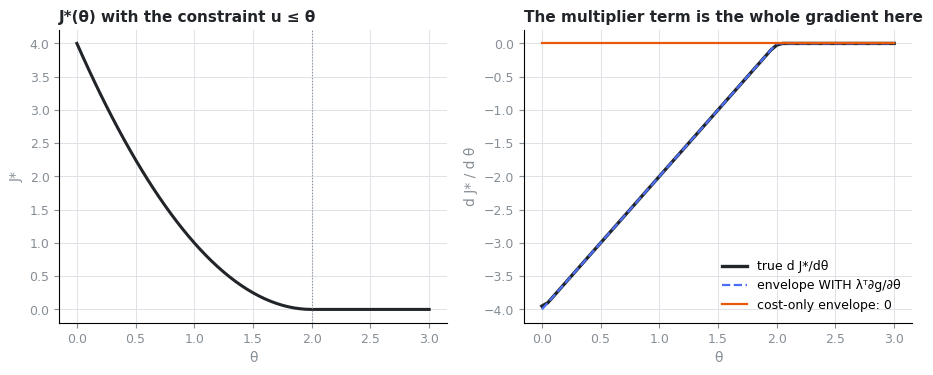

In [3]:
th = np.linspace(0.0, 3.0, 61)
u_s = np.minimum(th, 2.0)                    # active for theta < 2
J_s = (u_s - 2.0) ** 2
lam = np.where(th < 2.0, -2.0 * (th - 2.0), 0.0)   # KKT multiplier of u - theta <= 0
grad_cost_only = np.zeros_like(th)           # theta is not in the cost
grad_full = grad_cost_only + lam * (-1.0)    # + lambda * d(u - theta)/d theta

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(th, J_s, color=INK, lw=2.2)
axes[0].axvline(2.0, color=MUT, lw=0.8, ls=":")
tidy(axes[0], "J*(θ) with the constraint u ≤ θ", "θ", "J*")
axes[1].plot(th, np.gradient(J_s, th), color=INK, lw=2.4, label="true d J*/dθ")
axes[1].plot(th, grad_full, "--", color=BLUE, lw=1.6, label="envelope WITH λᵀ∂g/∂θ")
axes[1].plot(th, grad_cost_only, color=ORANGE, lw=1.6, label="cost-only envelope: 0")
tidy(axes[1], "The multiplier term is the whole gradient here", "θ", "d J* / d θ")
axes[1].legend(frameon=False, fontsize=9)
plt.show()

Measured on the real controller with an opponent 0.526 m away (keep-out
0.54 m, so the row was binding): acados' native gradient gave
$\partial V/\partial d_{obs} = +51.9$, the cost-only envelope gave
$0.000$, and the seven other weights agreed to 0.0%. The missing term was
the second-largest component of the whole gradient. The repo now uses the
native `eval_and_get_optimal_value_gradient("p_global")` whenever an
opponent is present.

## 3. TD(λ): one scalar per tick into a value estimate

Reinforcement learning's basic object is the **value** of a state, the
discounted sum of future rewards:

$$
V(s_t) = \mathbb{E}\Big[\sum_{k\ge 0} \gamma^k r_{t+k}\Big].
$$

Temporal-difference learning estimates it without waiting for the future,
from the one-step inconsistency between successive estimates — the
**TD error**:

$$
\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t).
$$

If $\delta_t > 0$ the world went better than $V(s_t)$ predicted, so $V(s_t)$
should go up. TD(λ) also credits *earlier* states through an **eligibility
trace** $e_t$, a decaying memory of where we have been:

$$
e_t = \gamma\lambda\, e_{t-1} + \nabla_w V(s_t), \qquad
w \leftarrow w + \alpha\, \delta_t\, e_t .
$$

$\lambda = 0$ credits only the current state; $\lambda \to 1$ credits the
whole trajectory. A lap is a ring of states with a reward somewhere on it —
so here is TD(λ) learning the value of every cell of a 20-cell ring.

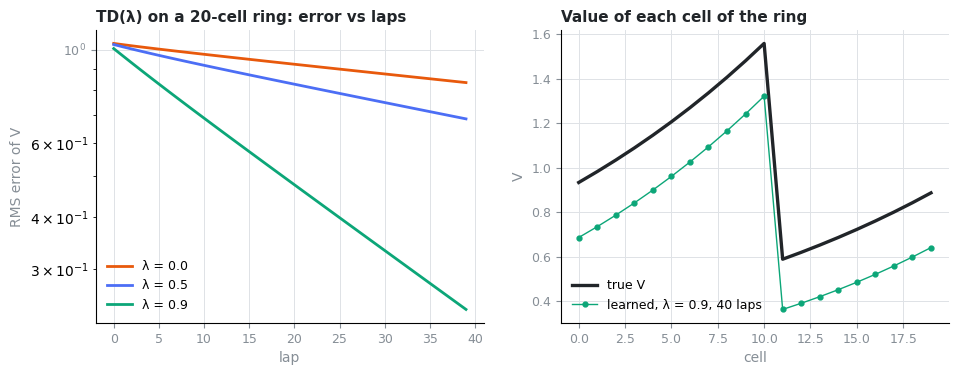

In [4]:
def td_lambda_ring(n_cells=20, gamma=0.95, lam=0.0, alpha=0.1, laps=40, seed=0):
    rng = np.random.default_rng(seed)
    reward = np.zeros(n_cells); reward[n_cells // 2] = 1.0        # one reward per lap
    # exact value by iterating the Bellman equation on the ring
    V_true = np.zeros(n_cells)
    for _ in range(2000):
        V_true = reward + gamma * np.roll(V_true, -1)
    V, e, err = np.zeros(n_cells), np.zeros(n_cells), []
    s = 0
    for lap in range(laps):
        for _ in range(n_cells):
            s_next = (s + 1) % n_cells
            delta = reward[s] + gamma * V[s_next] - V[s]
            e = gamma * lam * e; e[s] += 1.0                        # tabular: grad V = one-hot
            V += alpha * delta * e
            s = s_next
        err.append(np.sqrt(np.mean((V - V_true) ** 2)))
    return np.array(err), V, V_true


fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for lam, c in ((0.0, ORANGE), (0.5, BLUE), (0.9, GREEN)):
    err, V, V_true = td_lambda_ring(lam=lam)
    axes[0].plot(err, color=c, lw=2, label=f"λ = {lam}")
axes[0].set_yscale("log")
tidy(axes[0], "TD(λ) on a 20-cell ring: error vs laps", "lap", "RMS error of V")
axes[0].legend(frameon=False, fontsize=9)
axes[1].plot(V_true, color=INK, lw=2.4, label="true V")
axes[1].plot(V, "o-", color=GREEN, ms=3.5, lw=1, label="learned, λ = 0.9, 40 laps")
tidy(axes[1], "Value of each cell of the ring", "cell", "V")
axes[1].legend(frameon=False, fontsize=9)
plt.show()

Higher λ propagates the single reward backwards around the ring faster.
The real tuner uses $\gamma = 0.98$, $\lambda = 0.9$.

## 4. From a value to a policy update: the chain through the network

The tuner does not learn a table of values; it learns the **weight policy**
$\theta = \pi_\phi(\text{features})$. The policy is a small liquid-time-constant
(LTC) recurrent cell with hidden state $h$ and a linear readout $G$,
squashed so $\theta$ stays inside a box:

$$
\theta = \theta_0 + \mathrm{span}\cdot \tanh(G h), \qquad
\mathrm{span} = \begin{cases}\theta_{hi}-\theta_0 & \text{above}\\ \theta_0-\theta_{lo} & \text{below}\end{cases}
$$

$\theta_0$ is the **anchor** — a hand-tuned, stable, deliberately
unambitious weight vector (`baselines.START`). The policy learns deviations
from it. The update to $\phi = (G, \text{cell})$ is the TD step chained
through the policy:

$$
\phi \leftarrow \phi + \alpha\, \delta_t\, e_t, \qquad
e_t = \gamma\lambda\, e_{t-1} + \frac{\partial V}{\partial \theta}\frac{\partial \theta}{\partial \phi}.
$$

Two things about the squash matter in practice.

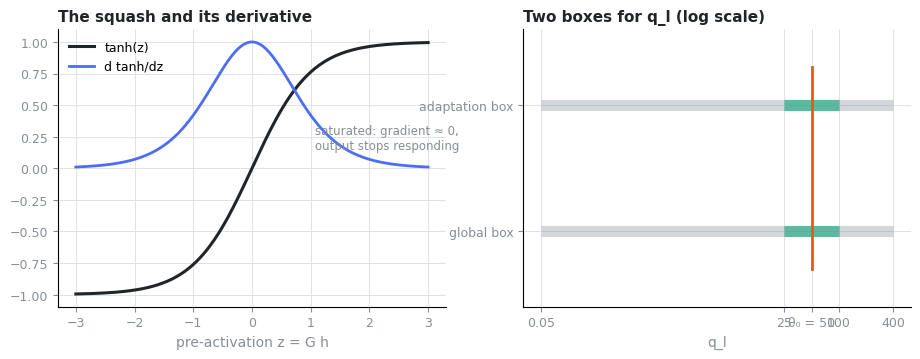

In [5]:
z = np.linspace(-3, 3, 200)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(z, np.tanh(z), color=INK, lw=2.2, label="tanh(z)")
axes[0].plot(z, 1 - np.tanh(z) ** 2, color=BLUE, lw=2, label="d tanh/dz")
tidy(axes[0], "The squash and its derivative", "pre-activation z = G h")
axes[0].legend(frameon=False, fontsize=9)
axes[0].annotate("saturated: gradient ≈ 0,\noutput stops responding", (2.3, 0.15),
                 fontsize=8.5, color=MUT, ha="center")

# the box: global search box vs a small adaptation box around theta_0
th0, glo, ghi = np.log(50.0), np.log(0.05), np.log(400.0)      # q_l as an example
alo, ahi = th0 - np.log(2), th0 + np.log(2)
axes[1].hlines([0.0, 1.0], glo, ghi, color=MUT, lw=8, alpha=0.35)
axes[1].hlines([0.0, 1.0], alo, ahi, color=GREEN, lw=8, alpha=0.6)
axes[1].plot([th0, th0], [-0.3, 1.3], color=ORANGE, lw=2)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(["global box", "adaptation box"])
axes[1].set_xticks([glo, alo, th0, ahi, ghi])
axes[1].set_xticklabels(["0.05", "25", "θ₀ = 50", "100", "400"])
tidy(axes[1], "Two boxes for q_l (log scale)", "q_l")
axes[1].set_ylim(-0.6, 1.6)
plt.show()

**Saturation.** Once $|Gh|$ is large the derivative of the squash is
near zero, the output stops depending on the input, and the policy freezes
wherever it arrived. Every early run ended there: a weight pinned on a
bound. **The box.** The global search box spans four orders of magnitude
for $q_l$; a controller that is meant to *adapt* around a working anchor
should be allowed to move a weight by a factor of two, not eight thousand.
`baselines.adaptation_box(track, factor=2)` is the green box. It made the
learner safe (no more crashes) — but, as the next section shows, it could
not make it useful, because the problem is the *direction*.

## 5. Why the original design walks to a corner

The original critic is the controller's own optimal cost: $V = -J^*(\theta)$.
It is available every tick for free and its gradient is the envelope
gradient from §2. It has one fatal property.

For a penalty weight $q$ multiplying a squared error, $\partial J^*/\partial q
= \sum e^{*2} \ge 0$ **always**. For the progress weight,
$\partial J^*/\partial q_v = -\sum v_s^* < 0$ **always**. So the direction
$\partial V/\partial\theta$ points the same way at every state, before the
car has moved: *raise $q_v$, cut every penalty*. The TD error only supplies
the **sign** of the step. And that sign is set by comparing a reward in
metres (or seconds) against a value in *cost units* — whichever scale is
larger wins. Change the units of the reward and the learner reverses.

The toy: three weights, a "controller cost" whose gradient is constant, and
a true return that peaks at an *interior* $\theta^*$ the learner should find.

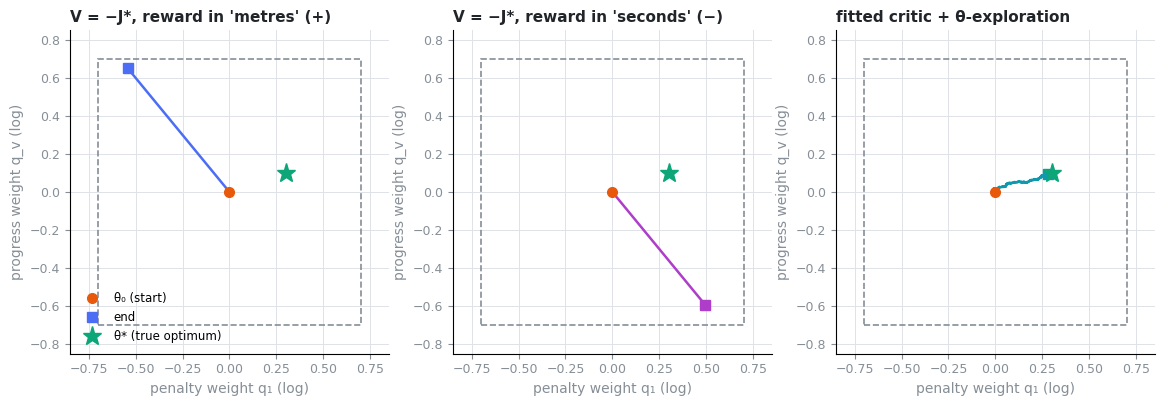

In [6]:
def run_actor(critic, reward_scale, steps=1500, alpha=0.05, gamma=0.98, sigma=0.15, seed=0):
    """Toy actor in a 3-weight box. critic='mpcc' uses V = -J*; 'fitted' learns V from the return."""
    rng = np.random.default_rng(seed)
    lo, hi = np.array([-0.7, -0.7, -0.7]), np.array([0.7, 0.7, 0.7])   # log-space adaptation box
    theta_star = np.array([0.3, -0.2, 0.1])                            # where the return actually peaks
    c = np.array([1.0, 0.8, -1.2])                                      # dJ*/dtheta: +,+ penalties, - progress
    def J_star(th): return 5.0 + c @ th                                  # cost with a CONSTANT gradient
    def true_return(th): return reward_scale * (1.0 - np.sum((th - theta_star) ** 2))
    theta = np.zeros(3)
    w = np.zeros(4)                                                     # fitted critic: linear in (theta, 1)
    traj = [theta.copy()]
    for t in range(steps):
        eps = rng.normal(0.0, sigma, 3) if critic == "fitted" else np.zeros(3)
        th_used = np.clip(theta + eps, lo, hi)
        r = true_return(th_used) + rng.normal(0.0, 0.02 * abs(reward_scale))
        if critic == "mpcc":
            V_now, V_next = -J_star(theta), -J_star(theta)               # theta barely changes per tick
            delta = r + gamma * V_next - V_now
            direction = -c                                               # dV/dtheta = -dJ*/dtheta, FIXED
            theta = np.clip(theta + alpha * np.sign(delta) * 0.01 * direction, lo, hi)
        else:
            x = np.append(theta, 1.0)
            V_now = w @ x
            delta = r - V_now                                            # advantage under the fitted critic
            w += 0.05 * delta * x                                        # critic: TD(0), gamma folded into r here
            theta = np.clip(theta + alpha * 0.02 * delta * eps / sigma ** 2, lo, hi)   # score-function actor
        traj.append(theta.copy())
    return np.array(traj), theta_star, (lo, hi)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (critic, scale, title, col) in zip(axes, (
        ("mpcc", +1.0, "V = −J*, reward in 'metres' (+)", BLUE),
        ("mpcc", -1.0, "V = −J*, reward in 'seconds' (−)", PURPLE),
        ("fitted", +1.0, "fitted critic + θ-exploration", CYAN))):
    traj, ts, (lo, hi) = run_actor(critic, scale)
    ax.add_patch(matplotlib.patches.Rectangle((lo[0], lo[2]), hi[0] - lo[0], hi[2] - lo[2],
                                              fill=False, ec=MUT, lw=1.2, ls="--"))
    ax.plot(traj[:, 0], traj[:, 2], color=col, lw=1.8)
    ax.plot(traj[0, 0], traj[0, 2], "o", color=ORANGE, ms=7, label="θ₀ (start)")
    ax.plot(traj[-1, 0], traj[-1, 2], "s", color=col, ms=7, label="end")
    ax.plot(ts[0], ts[2], "*", color=GREEN, ms=14, label="θ* (true optimum)")
    tidy(ax, title, "penalty weight q₁ (log)", "progress weight q_v (log)")
    ax.set_xlim(-0.85, 0.85); ax.set_ylim(-0.85, 0.85)
axes[0].legend(frameon=False, fontsize=8.5, loc="lower left")
plt.show()

Left and middle: the same learner, the same start, the same optimum — and
**opposite corners**, decided by nothing but the sign of the reward's units.
Neither goes anywhere near $\theta^*$. This is exactly what was measured on
the real car (TODO §2w): per-tick TD on a progress reward drove $q_v$ to its
ceiling and every penalty to its floor; per-metre TD on a time reward drove
them all the other way, on every seed.

Right: a critic that **never sees $\theta$** and an actor that learns from
what its own perturbations did to the return walks to the optimum.

## 6. The fix: a critic fitted to the return, θ only through the policy

Replace $V = -J^*$ with a value function of the *features* the policy sees,
trained on the actual reward:

$$
V_w(x) = w^\top x, \qquad
\delta_t = r_t + \gamma V_w(x_{t+1}) - V_w(x_t), \qquad
w \leftarrow w + \alpha_c\, \delta_t\, e^w_t .
$$

The actor then needs a direction that does not come from $J^*$. Perturb the
policy's output, $\theta_t = \pi_\phi(x_t) + \varepsilon_t$,
$\varepsilon_t \sim \mathcal N(0, \sigma^2 I)$, and use the
**score-function (REINFORCE) estimator** with the critic's $\delta$ as the
advantage:

$$
\nabla_\phi \log \pi(\theta_t | x_t) = \frac{\varepsilon_t}{\sigma^2}\,
  \frac{\partial \pi_\phi(x_t)}{\partial \phi}, \qquad
\phi \leftarrow \phi + \alpha\, \delta_t\, e^\phi_t, \quad
e^\phi_t = \gamma\lambda\, e^\phi_{t-1} + \nabla_\phi \log \pi(\theta_t|x_t).
$$

A perturbation that was followed by a better-than-expected return
($\delta>0$) is reinforced; one followed by worse is suppressed. $\theta$
enters the return only through the policy — the critic is blind to it, so
there is no fixed direction for units to flip. This is `critic="fitted"` in
`PolicyTuner`. The actuator exploration the original design used is switched
off; measured on T2 it cost 0.28 laps for no information.

## 7. Learning per metre, not per tick

The learner used to take one step per control tick. Then a slow car updates
many times per metre and a fast one few; the trace decays in *seconds*, so
credit spans less track when slow; and the "situation" is indexed by a
moment when it should be a place. Semi-Markov TD(λ) takes one step per
$\Delta s_{ref}$ metres of real progress, with $n = \Delta s/\Delta s_{ref}$:

$$
\delta = r + \gamma^{n} V' - V, \qquad e \leftarrow (\gamma\lambda)^{n} e + \nabla V .
$$

**The reward must change with the clock.** With a progress clock, a reward
of "progress" would give exactly 1 per metre and delete speed from the
objective; the reward becomes $-\Delta t$, time spent, so the return is
minus the lap time — the racing objective stated directly.

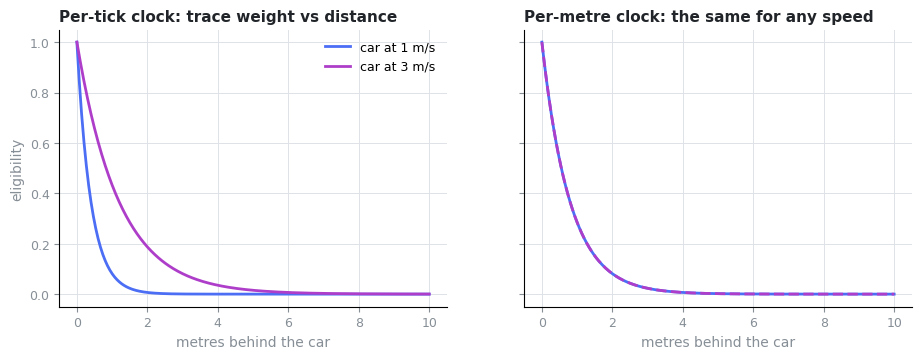

In [7]:
s = np.linspace(0, 10, 300)                        # metres of track behind the car
gamma_lam = 0.98 * 0.9
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for v, c in ((1.0, BLUE), (3.0, PURPLE)):
    t = s / v                                      # seconds it took to cover s metres
    axes[0].plot(s, gamma_lam ** (t / 0.05), color=c, lw=2, label=f"car at {v:.0f} m/s")
    axes[1].plot(s, gamma_lam ** (s / 0.10), color=c, lw=2, ls="-" if v == 1 else "--")
tidy(axes[0], "Per-tick clock: trace weight vs distance", "metres behind the car", "eligibility")
tidy(axes[1], "Per-metre clock: the same for any speed", "metres behind the car")
axes[0].legend(frameon=False, fontsize=9)
plt.show()

Under the per-tick clock a fast car's trace reaches three times further back
along the track than a slow car's; under the per-metre clock the credit
horizon is a fixed length of track.

## 8. Keep the network, and only after checking it

Even a learner walking the wrong way passes through good weights. The
safety net is **keep-best-and-revert on the network**: snapshot the policy
parameters $(G, \text{cell})$ at the end of the best episode and restore
them when a later episode is worse by more than the seed noise, or crashes.
The weights stay a *function* of the situation; the function is what is
banked.

One subtlety was measured the hard way. An episode's score is produced by
the network *as it changes through the episode*, plus exploration noise —
not by the snapshot at its end. Banked networks credited with 2.32 / 2.34 /
2.47 laps drove, frozen, 2.11 / 2.06-then-crash / 1.83. So a candidate is now
**validated**: one frozen episode (no learning, no noise) scores it, and it
is banked only at that frozen score, only if it beats the validated
incumbent, never if it crashed.

```
after each learning episode with score s:
    if s > best_validated:           candidate = snapshot(network)
                                     s_frozen  = drive(candidate, frozen=True)
                                     if s_frozen > best_validated: bank(candidate, s_frozen)
    elif s < best_validated - tol or crashed:
                                     restore(best network)
```

## 9. Where this lives in the code

| Idea | Where |
|---|---|
| envelope gradient, cost-only | `mpcc_tuning/acados_grad.py` |
| native gradient incl. $\lambda^\top\partial g/\partial\theta$ | `AcadosMPCC.grad_theta` (`theta_global=True`) |
| TD(λ), traces, the chain through the policy | `mpcc_tuning/ltc.py::PolicyTuner.learn` |
| the squash and the anchor | `mpcc_tuning/ltc.py::WeightPolicy` |
| adaptation box | `mpcc_tuning/baselines.py::adaptation_box` |
| per-metre clock | `PolicyTuner(clock="progress")` |
| fitted critic + θ-exploration | `PolicyTuner(critic="fitted", theta_explore=σ)` |
| keep-best with validation | `PolicyTuner.end_episode / confirm_candidate` |
| the experiment that runs all of it | `experiments/online_from_baseline.py` |

The measurements referred to above — the 51.9 vs 0 gradient, the opposite
corners, the 2.32 → 2.11 banking gap — are all in `TODO.md` with the runs
that produced them, and the figures are in `paper/figures/`.